In [4]:
from state import MessagesState
from langgraph.types import interrupt
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage, SystemMessage
from preprocessor.config.null_handler import null_handler_config
from preprocessor.model import *
from preprocessor.null_handler_tools import *

def build_preprocessor_subgraph(config: dict):
    def analysis_node(state):
        # try:
        #     import pickle
        #     with open("pickles/struct_state.pkl", "wb") as f:
        #         pickle.dump(state, f)
        # except Exception as e:
        #     print(f"Error at {e}")
        struct_model = small_model.with_structured_output(config["analysis_schema"])
        analysis_prompt = config["analysis_prompt"].format(context = state["struct"])
        recommendations = struct_model.invoke(analysis_prompt)
        # import pickle
        # with open("pickles/state.pkl", "rb") as f:
        #     loaded_state = pickle.load(f)
            
        return {"analysis": recommendations.model_dump_json()}
        # return {"analysis": loaded_state['analysis']}

    def struct_node(state):

        import pickle
        with open("pickles/state.pkl", "rb") as f:
            loaded_state = pickle.load(f)
            

        # struct_model = model.with_structured_output(config["struct_schema"])
        # options_dict = struct_model.invoke([SystemMessage(content=config["model_context"]),HumanMessage(content=config["struct_prompt"])])
        # return {"struct": options_dict.model_dump_json()}
        return {"struct": loaded_state['struct']}

    def ask_user_node(state):
        try:
            import pickle
            with open("pickles/analysis_state.pkl", "wb") as f:
                pickle.dump(state, f)
        except Exception as e:
            print(f"Error at {e}")
        user_choice = interrupt({
            "analysis": state["analysis"],
            "struct": state["struct"]
        })
        return {"user_choice": user_choice}
    def update_dataset(state):
        try:
            import pickle
            with open("pickles/update_state.pkl", "wb") as f:
                pickle.dump(state, f)

            impute_columns = state["user_choice"]["fill_with_average"]
            drop_columns = state["user_choice"]["drop_column"]
            drop_rows = state["user_choice"]["drop_rows"]
            
            impute_response = replace_with_avg(impute_columns) if len(impute_columns) > 0 else []
            col_drop_response = drop_column(drop_columns) if len(drop_columns) > 0 else []
            row_drop_response = drop_all_rows(drop_rows) if len(drop_rows) > 0 else []
            
        except Exception as e:
            print(f"Error at {e}")   
        return {'update': [impute_response, col_drop_response, row_drop_response]}     
              
    graph_builder = StateGraph(MessagesState)
    graph_builder.add_node("analysis", analysis_node)
    graph_builder.add_node("struct", struct_node)
    graph_builder.add_node("interrupt", ask_user_node)
    graph_builder.add_node("update", update_dataset)

    graph_builder.add_edge(START, "struct")
    graph_builder.add_edge("struct", "analysis")
    graph_builder.add_edge("analysis", "interrupt")
    graph_builder.add_edge("interrupt","update")
    graph_builder.add_edge("update", END)
    
    graph = graph_builder.compile()
    return graph
    # from IPython.display import Image, display
    # display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
# build_preprocessor_subgraph(null_handler_config)


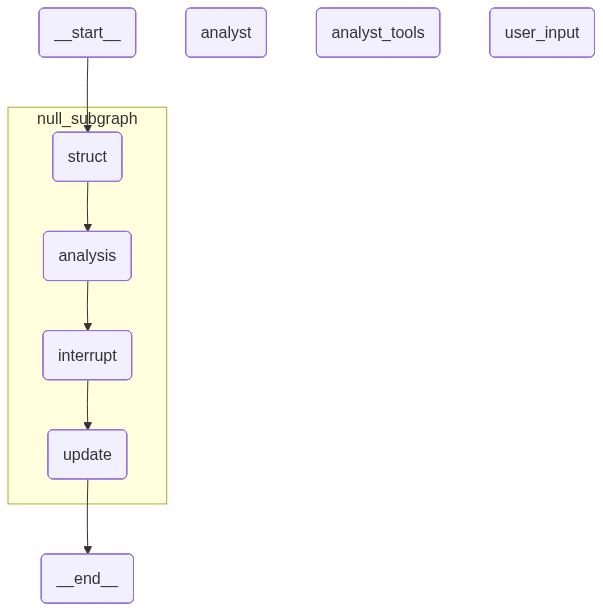

In [5]:

from analyst.nodes import analyst_call
from preprocessor.config.null_handler import null_handler_config
# from preprocessor.nodes import preprocessor_call
from state import should_continue, MessagesState, make_tool_node, ask_user_node, preprocessor_should_continue
from langgraph.graph import StateGraph, START, END
from analyst.tools import tools_by_name as analyst_tools
from langgraph.checkpoint.memory import InMemorySaver
import uuid



# Build workflow
agent_builder = StateGraph(MessagesState)
analyst_tool_node = make_tool_node(analyst_tools)
null_subgraph = build_preprocessor_subgraph(null_handler_config)
# Add nodes
agent_builder.add_node("analyst", analyst_call)
agent_builder.add_node("analyst_tools", analyst_tool_node)
agent_builder.add_node("user_input",ask_user_node)
agent_builder.add_node("null_subgraph", null_subgraph)


# Add edges to connect nodes
# TEMPORARY
# agent_builder.add_edge(START, "analyst")
# agent_builder.add_conditional_edges(
#     "analyst",
#     should_continue,
#     ["analyst_tools", "null_subgraph"]
# )
# agent_builder.add_edge("analyst_tools", "analyst")

agent_builder.add_edge(START, "null_subgraph")
agent_builder.add_edge("null_subgraph", END)

# Compile the agent
checkpointer = InMemorySaver()
agent = agent_builder.compile(checkpointer=checkpointer)

config = {
    "configurable": {
        "thread_id": "chat-1",
    }
}


# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))



In [6]:
# Stream (required for interrupt to work)
from langchain.messages import HumanMessage, SystemMessage
messages = [SystemMessage(content="start your task"),HumanMessage(content="Analyze the data")]

# Use stream() instead of invoke() to enable input() functionality
for chunk in agent.stream({"messages": messages}, config):
    # Process each chunk as it arrives
    for node_name, node_output in chunk.items():
        print(f"\n[{node_name}]")
        if node_name == "__interrupt__":
            interrupt_payload = node_output
            break
        if "messages" in node_output and len(node_output["messages"]) > 0:
            last_message = node_output["messages"][-1]
            if hasattr(last_message, "content") and last_message.content:
                print(f"Content: {last_message.content}")
            if hasattr(last_message, "tool_calls") and last_message.tool_calls:
                print(f"Tool calls: {last_message.tool_calls}")
        else:
            print(f"Output: {node_output}")


[__interrupt__]


In [4]:
import pickle
with open("pickles/state.pkl", "rb") as f:
    loaded_state = pickle.load(f)

print(loaded_state['analysis'])
loaded_state['struct']

{"prompts":["For the 'Age' column, we recommend **replacing null values with the average age**.\n\n**Reasoning:** The average age is a suitable representative value for the missing data, preserving the dataset's size and distribution.\n\n**Possible Actions:**\n*   Drop column 'Age'\n*   Drop rows with null 'Age'\n*   Replace nulls in 'Age' with average","For the 'Salary' column, we recommend **dropping rows with null values**.\n\n**Reasoning:** Salary information is critical for analysis, and imputing it with an average might introduce bias. Dropping these rows will ensure data integrity.\n\n**Possible Actions:**\n*   Drop column 'Salary'\n*   Drop rows with null 'Salary'\n*   Replace nulls in 'Salary' with average","For the 'Experience' column, we recommend **dropping the entire column**.\n\n**Reasoning:** A high percentage of missing values in 'Experience' makes imputation unreliable and could skew the analysis. Removing the column is the most prudent approach.\n\n**Possible Actions:

'{"reasoning":"The \'Age\' column has a significant number of null values (177), but it is a crucial feature for analysis. Filling with the average age is a reasonable strategy to retain this information. The \'Cabin\' column has a very high percentage of null values (687), making it unsuitable for imputation and best to be dropped. The \'Embarked\' column has only 2 null values, which is a very small fraction of the data, so dropping these rows will not significantly impact the dataset.","drop_column":["Cabin"],"drop_rows":["Embarked"],"fill_with_average":["Age"]}'

In [ ]:
messages

[SystemMessage(content='dataset address: "datasets/Titanic-Dataset.csv"', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Analyze the data', additional_kwargs={}, response_metadata={})]

In [9]:
from langgraph.types import Command

# config = {"configurable": {"thread_id": "chat-1"}}

# # First run: hits interrupt and pauses
# result = agent.invoke({"input": "hi"}, config=config)
# print(result["__interrupt__"])

# Resume: this continues, and interrupt() returns this value

agent.invoke(Command(resume=

{
    "drop_column": ["Cabin"],
    "drop_rows": ["Embarked"],
    "fill_with_average": ["Age"],
}

),config=config)

{'messages': [SystemMessage(content='start your task', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Analyze the data', additional_kwargs={}, response_metadata={}),
  SystemMessage(content='start your task', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Analyze the data', additional_kwargs={}, response_metadata={})],
 'struct': '{"reasoning":"The \'Age\' column has a significant number of null values (177), but it is a crucial feature for analysis. Filling with the average age is a reasonable strategy to retain this information. The \'Cabin\' column has a very high percentage of null values (687), making it unsuitable for imputation and best to be dropped. The \'Embarked\' column has only 2 null values, which is a very small fraction of the data, so dropping these rows will not significantly impact the dataset.","drop_column":["Cabin"],"drop_rows":["Embarked"],"fill_with_average":["Age"]}',
 'analysis': '{"prompts":["The \'Cabin\' column ha

In [7]:
import json

for item in json.loads(interrupt_payload[0].value['analysis'])['prompts']:
    print(item, end = "\n\n\n\n")


The 'Cabin' column has a very high percentage of null values (687), making it unsuitable for imputation. We recommend dropping this column. Would you like to proceed with dropping the 'Cabin' column?



There are only 2 null values in the 'Embarked' column, which is a very small fraction of the data. We recommend dropping these rows to maintain data integrity. Would you like to proceed with dropping rows with null values in the 'Embarked' column?



The 'Age' column has a significant number of null values (177), but it is a crucial feature for analysis. Filling with the average age is a reasonable strategy to retain this information. Would you like to proceed with filling the null values in the 'Age' column with the average age?





In [30]:
json.loads(interrupt_payload[0].value['analysis'])['prompts']

["For the 'Age' column, we recommend **replacing null values with the average age**.\n\n**Reasoning:** The average age is a suitable representative value for the missing data, preserving the dataset's size and distribution.\n\n**Possible Actions:**\n*   Drop column 'Age'\n*   Drop rows with null 'Age'\n*   Replace nulls in 'Age' with average",
 "For the 'Salary' column, we recommend **dropping rows with null values**.\n\n**Reasoning:** Salary information is critical for analysis, and imputing it with an average might introduce bias. Dropping these rows will ensure data integrity.\n\n**Possible Actions:**\n*   Drop column 'Salary'\n*   Drop rows with null 'Salary'\n*   Replace nulls in 'Salary' with average",
 "For the 'Experience' column, we recommend **dropping the entire column**.\n\n**Reasoning:** A high percentage of missing values in 'Experience' makes imputation unreliable and could skew the analysis. Removing the column is the most prudent approach.\n\n**Possible Actions:**\n*  